# Christian Chung - BIOE242 Project Checkpoint 2: ML Model Construction & Workflow Development

**Central question:** Can cell topology alone encode the tissue's mechanical (rheological) state?

This notebook constructs and validates all three model families:

| Model | Type | Role |
|-------|------|------|
| PCA + UMAP + K-Means | Unsupervised | Recover known solid/fluid phase boundaries without labels |
| MLP on pooled features | Supervised | **Null baseline** - topology-blind |
| GraphSAGE GNN | Supervised | **Primary model** - topology-aware |

## Learning tasks
1. **Binary (fluid vs solid):** classify each tissue snapshot as fluid-like (mean shape index q > 3.81) or solid-like (q <= 3.81); this is changed from the last time where we used ~3.7
2. **Multi-class (3 suite types):** predict which parameter was varied - Adhesion / DeformationEnergy / Proliferation

### Design note: 3-class instead of 4-class suite classification
From the last project checkpoint, I included a simulation that represented the control.
The Control simulation is a *baseline parameter setting* that represents the default tissue state
with no single mechanism being perturbed. The canonical parameters overlap with the
unperturbed end of each of the three suites. Including it as a 4th class creates two problems:
- **Class imbalance:** Control = 300 graphs vs. Adhesion/DeformEnergy = ~2,100 each
- **Ambiguous label:** the model cannot learn a clean separation because Control simultaneously
  sits at the baseline of all three suites

The 3-class formulation poses the cleaner scientific question: *"Which biological mechanism was
perturbed?"* - adhesion, deformation energy, or proliferation rate. Control graphs are retained
for the binary (fluid/solid) task where they contribute useful baseline-state snapshots.

## 1. Setup

In [1]:
import warnings
warnings.filterwarnings('ignore')

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, adjusted_rand_score, accuracy_score
from sklearn.preprocessing import LabelEncoder
import umap

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.optim import Adam

import torch_geometric
from torch_geometric.data import Data
from torch_geometric.loader import DataLoader
from torch_geometric.nn import SAGEConv, global_mean_pool

BANK = Path(r'c:/Users/cmchu/OneDrive/Desktop/Gu Lab/BIOE242 Data/BIOE242 Data Bank Complete')
SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {DEVICE}')
print(f'PyTorch Geometric: {torch_geometric.__version__}')

Device: cpu
PyTorch Geometric: 2.7.0


## 2. Load data & define labels

In [2]:
train_graphs = torch.load(BANK / 'train_graphs.pt', weights_only=False)
val_graphs   = torch.load(BANK / 'val_graphs.pt',   weights_only=False)
test_graphs  = torch.load(BANK / 'test_graphs.pt',  weights_only=False)

print(f'Train: {len(train_graphs)} | Val: {len(val_graphs)} | Test: {len(test_graphs)}')
print(f'Node feature dim: {train_graphs[0].x.shape[1]}')
print(f'Features: [area, perimeter, shape_index, n_neighbors]')

Train: 5984 | Val: 1737 | Test: 884
Node feature dim: 4
Features: [area, perimeter, shape_index, n_neighbors]


In [3]:
# Binary labels from raw (un-normalized) shape index vs q* = 3.81
SHAPE_IDX_THRESHOLD = 3.81

train_raw = torch.load(BANK / 'train_graphs_raw.pt', weights_only=False)
val_raw   = torch.load(BANK / 'val_graphs_raw.pt',   weights_only=False)
test_raw  = torch.load(BANK / 'test_graphs_raw.pt',  weights_only=False)

def get_mean_q(g_raw):
    return float(g_raw.x[:, 2].mean())

for g_norm, g_raw in zip(train_graphs, train_raw):
    mq = get_mean_q(g_raw)
    g_norm.binary_label = torch.tensor([1 if mq > SHAPE_IDX_THRESHOLD else 0], dtype=torch.long)
    g_norm.suite_label  = torch.tensor([int(g_norm.y[0].item())], dtype=torch.long)

for g_norm, g_raw in zip(val_graphs, val_raw):
    mq = get_mean_q(g_raw)
    g_norm.binary_label = torch.tensor([1 if mq > SHAPE_IDX_THRESHOLD else 0], dtype=torch.long)
    g_norm.suite_label  = torch.tensor([int(g_norm.y[0].item())], dtype=torch.long)

for g_norm, g_raw in zip(test_graphs, test_raw):
    mq = get_mean_q(g_raw)
    g_norm.binary_label = torch.tensor([1 if mq > SHAPE_IDX_THRESHOLD else 0], dtype=torch.long)
    g_norm.suite_label  = torch.tensor([int(g_norm.y[0].item())], dtype=torch.long)

# 3-class suite splits: drop Control (suite_label==0), remap 1/2/3 -> 0/1/2
# Original encoding: 0=Control, 1=Adhesion, 2=DeformEnergy, 3=Proliferation
# 3-class:                       0=Adhesion, 1=DeformEnergy, 2=Proliferation
SUITE_NAMES_3  = ['Adhesion', 'DeformEnergy', 'Proliferation']
SUITE_COLORS_3 = ['#1f77b4', '#d62728', '#2ca02c']

def make_suite3_split(graphs):
    out = []
    for g in graphs:
        s = g.suite_label.item()
        if s == 0:
            continue
        gc = g.clone()
        gc.suite_label_3 = torch.tensor([s - 1], dtype=torch.long)
        out.append(gc)
    return out

train_suite3 = make_suite3_split(train_graphs)
val_suite3   = make_suite3_split(val_graphs)
test_suite3  = make_suite3_split(test_graphs)

all_graphs = train_graphs + val_graphs + test_graphs

n_fluid = sum(g.binary_label.item() for g in train_graphs)
n_solid = len(train_graphs) - n_fluid
print(f'Binary -- train fluid: {n_fluid} | solid: {n_solid}')

s3_counts = pd.Series([g.suite_label_3.item() for g in train_suite3]).value_counts().sort_index()
s3_counts.index = SUITE_NAMES_3
print(f'\n3-class suite -- train (Control excluded):')
print(s3_counts)
print(f'train_suite3: {len(train_suite3)} | val: {len(val_suite3)} | test: {len(test_suite3)}')

Binary -- train fluid: 5547 | solid: 437

3-class suite -- train (Control excluded):
Adhesion         2100
DeformEnergy     2100
Proliferation    1484
Name: count, dtype: int64
train_suite3: 5684 | val: 1737 | test: 884


## 3. Graph-level feature vectors (for unsupervised + MLP)

In [4]:
def graphs_to_matrix(graphs):
    """Pool each graph into a fixed 8-dim vector: mean + std of node features.
    [mean_area, mean_perim, mean_q, mean_deg, std_area, std_perim, std_q, std_deg]
    """
    rows = []
    for g in graphs:
        mean = g.x.mean(dim=0).numpy()
        std  = g.x.std(dim=0).numpy()
        rows.append(np.concatenate([mean, std]))
    return np.array(rows)

X_train = graphs_to_matrix(train_graphs)
X_val   = graphs_to_matrix(val_graphs)
X_test  = graphs_to_matrix(test_graphs)
X_all   = np.concatenate([X_train, X_val, X_test])

X_train_s3 = graphs_to_matrix(train_suite3)
X_val_s3   = graphs_to_matrix(val_suite3)
X_test_s3  = graphs_to_matrix(test_suite3)
X_s3_all   = np.concatenate([X_train_s3, X_val_s3, X_test_s3])

y_binary_all = np.array([g.binary_label.item() for g in all_graphs])
y_suite_all  = np.array([g.suite_label.item()  for g in all_graphs])   # 4-class (vis only)
y_suite3_all = np.array([g.suite_label_3.item()
                         for g in (train_suite3 + val_suite3 + test_suite3)])

print(f'Feature matrix (all graphs): {X_all.shape}')
print(f'Feature matrix (suite3):     {X_s3_all.shape}')
print('Features: mean[area, perim, shape_idx, n_neighbors] + std[...]')

Feature matrix (all graphs): (8605, 8)
Feature matrix (suite3):     (8305, 8)
Features: mean[area, perim, shape_idx, n_neighbors] + std[...]


## 4. Unsupervised analysis: PCA + UMAP + K-Means

Explained variance ratio (cumulative):
  PC1: 0.488  (cumulative: 0.488)
  PC2: 0.387  (cumulative: 0.875)
  PC3: 0.081  (cumulative: 0.956)
  PC4: 0.024  (cumulative: 0.980)


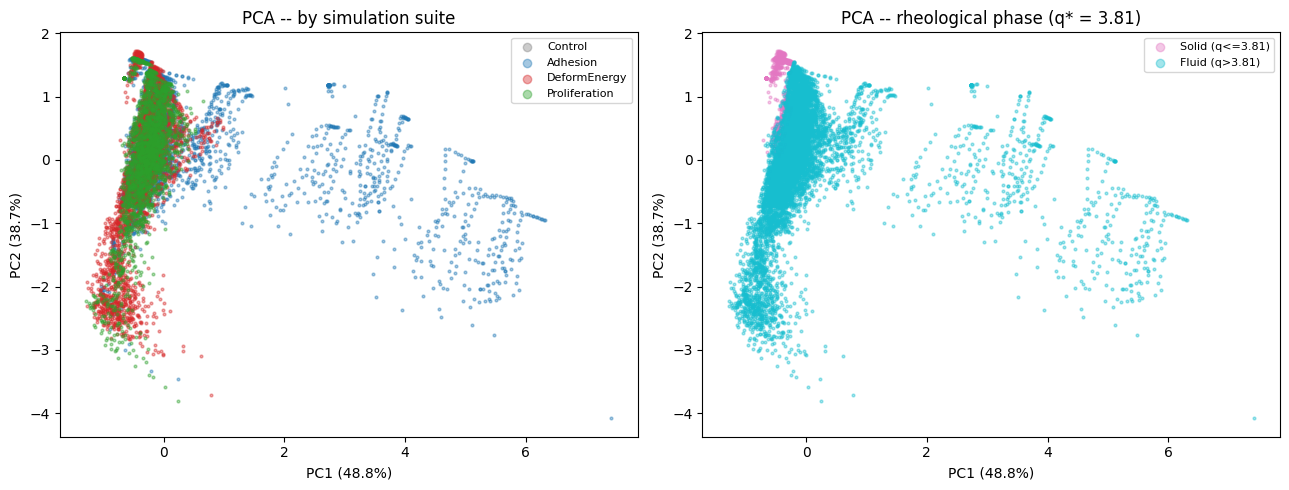

Saved pca_plot.png


In [5]:
# PCA
pca = PCA(n_components=4, random_state=SEED)
Z_pca = pca.fit_transform(X_all)

print('Explained variance ratio (cumulative):')
cum_var = np.cumsum(pca.explained_variance_ratio_)
for i, (v, cv) in enumerate(zip(pca.explained_variance_ratio_, cum_var)):
    print(f'  PC{i+1}: {v:.3f}  (cumulative: {cv:.3f})')

suite_names_4  = ['Control', 'Adhesion', 'DeformEnergy', 'Proliferation']
suite_colors_4 = ['gray', '#1f77b4', '#d62728', '#2ca02c']

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for s, (name, color) in enumerate(zip(suite_names_4, suite_colors_4)):
    mask = y_suite_all == s
    axes[0].scatter(Z_pca[mask, 0], Z_pca[mask, 1], c=color, s=4, alpha=0.4, label=name)
axes[0].set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%})')
axes[0].set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%})')
axes[0].set_title('PCA -- by simulation suite')
axes[0].legend(markerscale=3, fontsize=8)

for lab, name, color in [(0, 'Solid (q<=3.81)', '#e377c2'), (1, 'Fluid (q>3.81)', '#17becf')]:
    mask = y_binary_all == lab
    axes[1].scatter(Z_pca[mask, 0], Z_pca[mask, 1], c=color, s=4, alpha=0.4, label=name)
axes[1].set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%})')
axes[1].set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%})')
axes[1].set_title('PCA -- rheological phase (q* = 3.81)')
axes[1].legend(markerscale=3, fontsize=8)

plt.tight_layout()
plt.savefig(BANK / 'pca_plot.png', dpi=150)
plt.show()
print('Saved pca_plot.png')

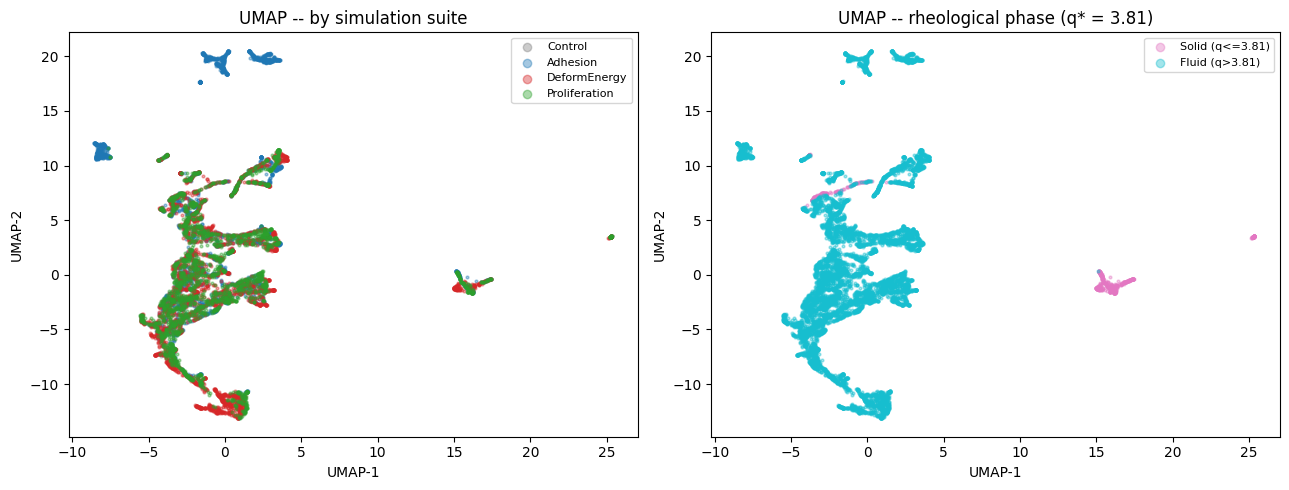

Saved umap_plot.png


In [6]:
# UMAP
reducer = umap.UMAP(n_components=2, n_neighbors=30, min_dist=0.1,
                    random_state=SEED, verbose=False)
Z_umap = reducer.fit_transform(X_all)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for s, (name, color) in enumerate(zip(suite_names_4, suite_colors_4)):
    mask = y_suite_all == s
    axes[0].scatter(Z_umap[mask, 0], Z_umap[mask, 1], c=color, s=4, alpha=0.4, label=name)
axes[0].set_xlabel('UMAP-1'); axes[0].set_ylabel('UMAP-2')
axes[0].set_title('UMAP -- by simulation suite')
axes[0].legend(markerscale=3, fontsize=8)

for lab, name, color in [(0, 'Solid (q<=3.81)', '#e377c2'), (1, 'Fluid (q>3.81)', '#17becf')]:
    mask = y_binary_all == lab
    axes[1].scatter(Z_umap[mask, 0], Z_umap[mask, 1], c=color, s=4, alpha=0.4, label=name)
axes[1].set_xlabel('UMAP-1'); axes[1].set_ylabel('UMAP-2')
axes[1].set_title('UMAP -- rheological phase (q* = 3.81)')
axes[1].legend(markerscale=3, fontsize=8)

plt.tight_layout()
plt.savefig(BANK / 'umap_plot.png', dpi=150)
plt.show()
print('Saved umap_plot.png')

  K   Silhouette   ARI (suite3)   ARI (binary)
--------------------------------------------------


  2       0.6752         0.0109        -0.0601


  3       0.4677         0.0190        -0.0812


  4       0.3662         0.0208         0.0201


  5       0.3670         0.0156         0.0184


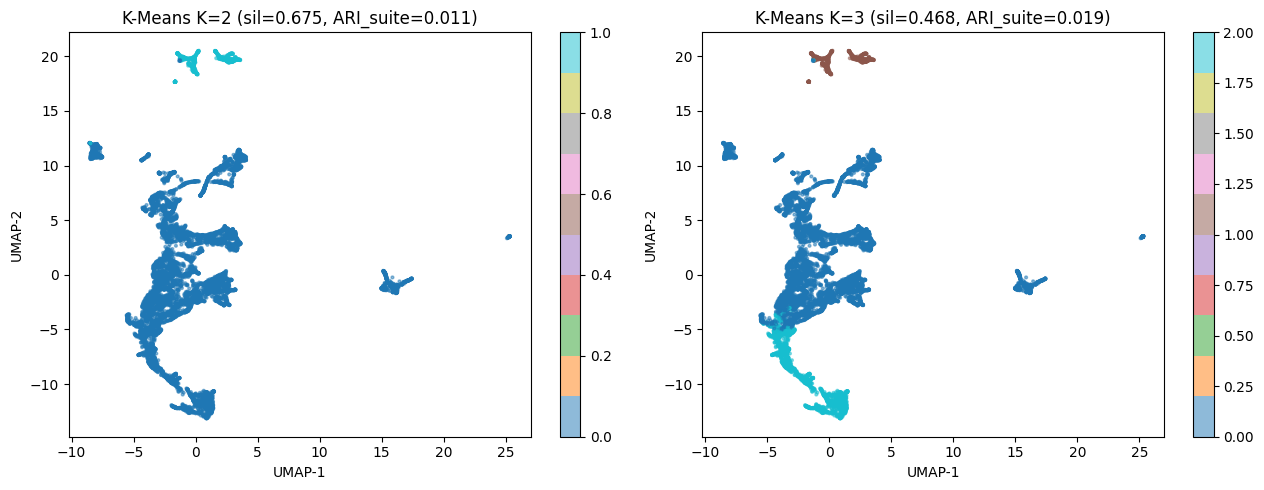

Saved kmeans_umap.png


In [7]:
# K-Means (K = 2, 3, 4, 5) -- ARI evaluated against 3-class suite labels
K_values = [2, 3, 4, 5]
kmeans_results = {}

print(f'  K   Silhouette   ARI (suite3)   ARI (binary)')
print('-' * 50)

for K in K_values:
    km = KMeans(n_clusters=K, random_state=SEED, n_init=10)
    labels    = km.fit_predict(X_all)
    sil       = silhouette_score(X_all, labels)
    labels_s3 = km.predict(X_s3_all)
    ari_suite  = adjusted_rand_score(y_suite3_all, labels_s3)
    ari_binary = adjusted_rand_score(y_binary_all, labels)
    kmeans_results[K] = {'labels': labels, 'sil': sil,
                         'ari_suite': ari_suite, 'ari_binary': ari_binary}
    print(f'  {K}   {sil:10.4f}   {ari_suite:12.4f}   {ari_binary:12.4f}')

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for ax, K in zip(axes, [2, 3]):
    labels = kmeans_results[K]['labels']
    scatter = ax.scatter(Z_umap[:, 0], Z_umap[:, 1], c=labels, cmap='tab10', s=4, alpha=0.5)
    ax.set_xlabel('UMAP-1'); ax.set_ylabel('UMAP-2')
    r = kmeans_results[K]
    ax.set_title(f'K-Means K={K} (sil={r["sil"]:.3f}, ARI_suite={r["ari_suite"]:.3f})')
    plt.colorbar(scatter, ax=ax)
plt.tight_layout()
plt.savefig(BANK / 'kmeans_umap.png', dpi=150)
plt.show()
print('Saved kmeans_umap.png')

## 5. MLP baseline (topology-blind null hypothesis)

In [8]:
class MLP(nn.Module):
    """
    Topology-blind baseline.
    Input: 8-dim pooled graph features (mean + std of node features).
    No access to graph structure -- only aggregated scalars.
    """
    def __init__(self, in_dim=8, hidden=64, n_classes=2):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_dim, hidden),
            nn.BatchNorm1d(hidden),
            nn.ReLU(),
            nn.Linear(hidden, hidden // 2),
            nn.BatchNorm1d(hidden // 2),
            nn.ReLU(),
            nn.Linear(hidden // 2, n_classes),
        )

    def forward(self, x):
        return self.net(x)

mlp_binary = MLP(in_dim=8, hidden=64, n_classes=2).to(DEVICE)
mlp_suite  = MLP(in_dim=8, hidden=64, n_classes=3).to(DEVICE)   # 3-class
dummy = torch.randn(4, 8).to(DEVICE)
print('MLP binary output:', mlp_binary(dummy).shape)
print('MLP suite  output:', mlp_suite(dummy).shape)
print('\nMLP (binary):')
print(mlp_binary)

MLP binary output: torch.Size([4, 2])
MLP suite  output: torch.Size([4, 3])

MLP (binary):
MLP(
  (net): Sequential(
    (0): Linear(in_features=8, out_features=64, bias=True)
    (1): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Linear(in_features=64, out_features=32, bias=True)
    (4): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): ReLU()
    (6): Linear(in_features=32, out_features=2, bias=True)
  )
)


In [9]:
def make_tensor_dataset(graphs, label_attr):
    X = torch.tensor(graphs_to_matrix(graphs), dtype=torch.float)
    y = torch.tensor([getattr(g, label_attr).item() for g in graphs], dtype=torch.long)
    return torch.utils.data.TensorDataset(X, y)

def train_mlp(model, train_g, val_g, label_attr, n_epochs=60, lr=1e-3, batch_size=128):
    ds_train = make_tensor_dataset(train_g, label_attr)
    ds_val   = make_tensor_dataset(val_g,   label_attr)
    dl_train = torch.utils.data.DataLoader(ds_train, batch_size=batch_size, shuffle=True)
    dl_val   = torch.utils.data.DataLoader(ds_val,   batch_size=batch_size)

    opt = Adam(model.parameters(), lr=lr, weight_decay=1e-4)
    history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}

    for epoch in range(n_epochs):
        model.train()
        tot_loss, tot_correct, tot_n = 0, 0, 0
        for X_b, y_b in dl_train:
            X_b, y_b = X_b.to(DEVICE), y_b.to(DEVICE)
            opt.zero_grad()
            logits = model(X_b)
            loss = F.cross_entropy(logits, y_b)
            loss.backward()
            opt.step()
            tot_loss += loss.item() * len(y_b)
            tot_correct += (logits.argmax(1) == y_b).sum().item()
            tot_n += len(y_b)
        history['train_loss'].append(tot_loss / tot_n)
        history['train_acc'].append(tot_correct / tot_n)

        model.eval()
        with torch.no_grad():
            vl, vc, vn = 0, 0, 0
            for X_b, y_b in dl_val:
                X_b, y_b = X_b.to(DEVICE), y_b.to(DEVICE)
                logits = model(X_b)
                vl += F.cross_entropy(logits, y_b).item() * len(y_b)
                vc += (logits.argmax(1) == y_b).sum().item()
                vn += len(y_b)
        history['val_loss'].append(vl / vn)
        history['val_acc'].append(vc / vn)

        if (epoch + 1) % 20 == 0:
            tl = history['train_loss'][-1]
            ta = history['train_acc'][-1]
            vl2 = history['val_loss'][-1]
            va = history['val_acc'][-1]
            print(f'  Epoch {epoch+1:3d} | train loss {tl:.4f} acc {ta:.3f} | val loss {vl2:.4f} acc {va:.3f}')
    return history


print('Training MLP -- binary (fluid vs solid) ...')
hist_mlp_bin = train_mlp(mlp_binary, train_graphs, val_graphs, 'binary_label', n_epochs=60)

print('\nTraining MLP -- 3-class suite (Adhesion / DeformEnergy / Proliferation) ...')
hist_mlp_suite = train_mlp(mlp_suite, train_suite3, val_suite3, 'suite_label_3', n_epochs=60)

Training MLP -- binary (fluid vs solid) ...


  Epoch  20 | train loss 0.0138 acc 0.995 | val loss 0.0103 acc 0.999


  Epoch  40 | train loss 0.0109 acc 0.996 | val loss 0.0066 acc 0.999


  Epoch  60 | train loss 0.0100 acc 0.996 | val loss 0.0066 acc 0.999

Training MLP -- 3-class suite (Adhesion / DeformEnergy / Proliferation) ...


  Epoch  20 | train loss 0.8043 acc 0.609 | val loss 1.0358 acc 0.386


  Epoch  40 | train loss 0.7411 acc 0.650 | val loss 0.9793 acc 0.451


  Epoch  60 | train loss 0.6995 acc 0.678 | val loss 1.1489 acc 0.429


## 6. GNN -- GraphSAGE (topology-aware)

In [10]:
class GraphSAGEClassifier(nn.Module):
    """
    GraphSAGE: 3 message-passing layers + global mean pooling + MLP head.
    After 3 layers each node's embedding reflects the local tissue neighborhood
    up to 3 hops away. Global mean pooling collapses the variable-size node set
    into a fixed-dim graph embedding for classification.
    """
    def __init__(self, in_dim=4, hidden=64, n_classes=2, n_layers=3, dropout=0.3):
        super().__init__()
        self.convs = nn.ModuleList()
        self.bns   = nn.ModuleList()
        self.dropout = dropout

        self.convs.append(SAGEConv(in_dim, hidden))
        self.bns.append(nn.BatchNorm1d(hidden))
        for _ in range(n_layers - 1):
            self.convs.append(SAGEConv(hidden, hidden))
            self.bns.append(nn.BatchNorm1d(hidden))

        self.head = nn.Sequential(
            nn.Linear(hidden, hidden // 2),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden // 2, n_classes),
        )

    def forward(self, x, edge_index, batch):
        for conv, bn in zip(self.convs, self.bns):
            x = conv(x, edge_index)
            x = bn(x)
            x = F.relu(x)
            x = F.dropout(x, p=self.dropout, training=self.training)
        x = global_mean_pool(x, batch)
        return self.head(x)


gnn_binary = GraphSAGEClassifier(in_dim=4, hidden=64, n_classes=2).to(DEVICE)
gnn_suite  = GraphSAGEClassifier(in_dim=4, hidden=64, n_classes=3).to(DEVICE)   # 3-class

sample_batch = next(iter(DataLoader(train_graphs[:8], batch_size=8)))
out = gnn_binary(sample_batch.x.to(DEVICE),
                 sample_batch.edge_index.to(DEVICE),
                 sample_batch.batch.to(DEVICE))
print('GNN binary output:', out.shape)
print('\nGNN architecture:')
print(gnn_binary)

GNN binary output: torch.Size([8, 2])

GNN architecture:
GraphSAGEClassifier(
  (convs): ModuleList(
    (0): SAGEConv(4, 64, aggr=mean)
    (1-2): 2 x SAGEConv(64, 64, aggr=mean)
  )
  (bns): ModuleList(
    (0-2): 3 x BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  )
  (head): Sequential(
    (0): Linear(in_features=64, out_features=32, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.3, inplace=False)
    (3): Linear(in_features=32, out_features=2, bias=True)
  )
)


In [11]:
def make_pyg_loaders(train_g, val_g, label_attr, batch_size=64):
    def tag(graphs):
        out = []
        for g in graphs:
            gc = g.clone()
            gc.y_task = getattr(g, label_attr)
            out.append(gc)
        return out
    tl = DataLoader(tag(train_g), batch_size=batch_size, shuffle=True)
    vl = DataLoader(tag(val_g),   batch_size=batch_size)
    return tl, vl


def train_gnn(model, train_g, val_g, label_attr, n_epochs=60, lr=1e-3, batch_size=64):
    tl, vl = make_pyg_loaders(train_g, val_g, label_attr, batch_size)
    opt = Adam(model.parameters(), lr=lr, weight_decay=1e-4)
    history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}

    for epoch in range(n_epochs):
        model.train()
        tot_loss, tot_correct, tot_n = 0, 0, 0
        for batch in tl:
            batch = batch.to(DEVICE)
            y = batch.y_task.view(-1)
            opt.zero_grad()
            logits = model(batch.x, batch.edge_index, batch.batch)
            loss = F.cross_entropy(logits, y)
            loss.backward()
            opt.step()
            tot_loss += loss.item() * len(y)
            tot_correct += (logits.argmax(1) == y).sum().item()
            tot_n += len(y)
        history['train_loss'].append(tot_loss / tot_n)
        history['train_acc'].append(tot_correct / tot_n)

        model.eval()
        with torch.no_grad():
            vlo, vc, vn = 0, 0, 0
            for batch in vl:
                batch = batch.to(DEVICE)
                y = batch.y_task.view(-1)
                logits = model(batch.x, batch.edge_index, batch.batch)
                vlo += F.cross_entropy(logits, y).item() * len(y)
                vc  += (logits.argmax(1) == y).sum().item()
                vn  += len(y)
        history['val_loss'].append(vlo / vn)
        history['val_acc'].append(vc / vn)

        if (epoch + 1) % 20 == 0:
            tl2 = history['train_loss'][-1]
            ta  = history['train_acc'][-1]
            vl2 = history['val_loss'][-1]
            va  = history['val_acc'][-1]
            print(f'  Epoch {epoch+1:3d} | train loss {tl2:.4f} acc {ta:.3f} | val loss {vl2:.4f} acc {va:.3f}')
    return history


print('Training GNN -- binary (fluid vs solid) ...')
hist_gnn_bin = train_gnn(gnn_binary, train_graphs, val_graphs, 'binary_label', n_epochs=60)

print('\nTraining GNN -- 3-class suite (Adhesion / DeformEnergy / Proliferation) ...')
hist_gnn_suite = train_gnn(gnn_suite, train_suite3, val_suite3, 'suite_label_3', n_epochs=60)

Training GNN -- binary (fluid vs solid) ...


  Epoch  20 | train loss 0.0209 acc 0.991 | val loss 0.0107 acc 0.997


  Epoch  40 | train loss 0.0168 acc 0.992 | val loss 0.0064 acc 0.999


  Epoch  60 | train loss 0.0191 acc 0.993 | val loss 0.0102 acc 0.999

Training GNN -- 3-class suite (Adhesion / DeformEnergy / Proliferation) ...


  Epoch  20 | train loss 0.8604 acc 0.582 | val loss 0.9122 acc 0.423


  Epoch  40 | train loss 0.7848 acc 0.630 | val loss 1.0032 acc 0.377


  Epoch  60 | train loss 0.7254 acc 0.653 | val loss 1.2029 acc 0.421


## 7. Training curves & comparison

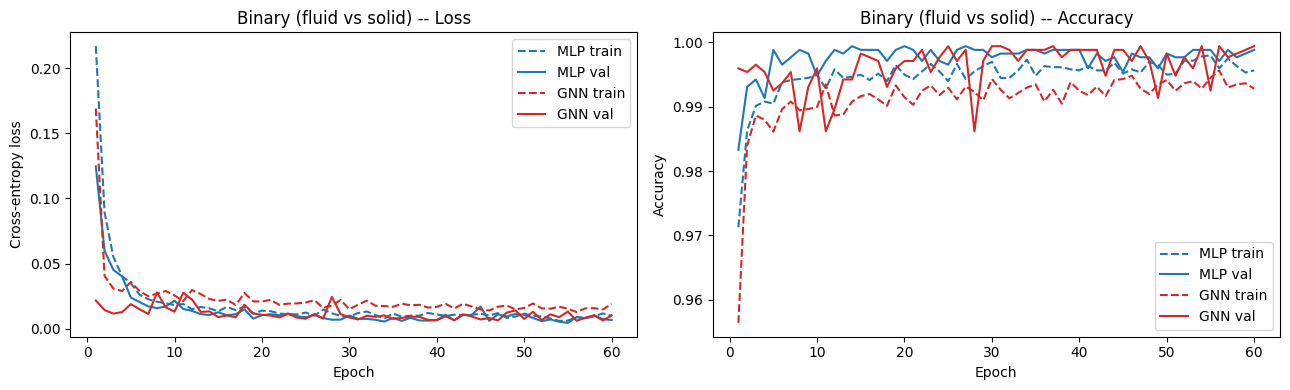

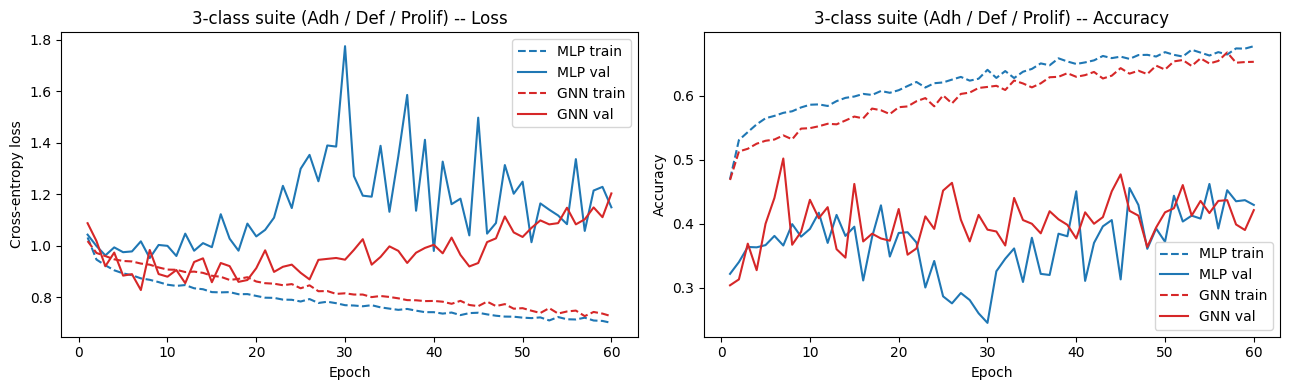

In [12]:
def plot_curves(hist_mlp, hist_gnn, task_name, save_name):
    fig, axes = plt.subplots(1, 2, figsize=(13, 4))
    epochs = range(1, len(hist_mlp['train_loss']) + 1)

    axes[0].plot(epochs, hist_mlp['train_loss'], '--', color='#1f77b4', label='MLP train')
    axes[0].plot(epochs, hist_mlp['val_loss'],   '-',  color='#1f77b4', label='MLP val')
    axes[0].plot(epochs, hist_gnn['train_loss'], '--', color='#d62728', label='GNN train')
    axes[0].plot(epochs, hist_gnn['val_loss'],   '-',  color='#d62728', label='GNN val')
    axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Cross-entropy loss')
    axes[0].set_title(f'{task_name} -- Loss')
    axes[0].legend()

    axes[1].plot(epochs, hist_mlp['train_acc'], '--', color='#1f77b4', label='MLP train')
    axes[1].plot(epochs, hist_mlp['val_acc'],   '-',  color='#1f77b4', label='MLP val')
    axes[1].plot(epochs, hist_gnn['train_acc'], '--', color='#d62728', label='GNN train')
    axes[1].plot(epochs, hist_gnn['val_acc'],   '-',  color='#d62728', label='GNN val')
    axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Accuracy')
    axes[1].set_title(f'{task_name} -- Accuracy')
    axes[1].legend()

    plt.tight_layout()
    plt.savefig(BANK / save_name, dpi=150)
    plt.show()

plot_curves(hist_mlp_bin,   hist_gnn_bin,   'Binary (fluid vs solid)',              'curves_binary.png')
plot_curves(hist_mlp_suite, hist_gnn_suite, '3-class suite (Adh / Def / Prolif)',   'curves_suite.png')

In [13]:
# Summary table
def eval_on_test(model, test_g, label_attr, model_type='gnn', batch_size=64):
    model.eval()
    all_preds, all_true = [], []
    with torch.no_grad():
        if model_type == 'mlp':
            X = torch.tensor(graphs_to_matrix(test_g), dtype=torch.float).to(DEVICE)
            y = torch.tensor([getattr(g, label_attr).item() for g in test_g])
            preds = model(X).argmax(1).cpu()
            return accuracy_score(y.numpy(), preds.numpy())
        else:
            def tag(graphs):
                out = []
                for g in graphs:
                    gc = g.clone(); gc.y_task = getattr(g, label_attr); out.append(gc)
                return out
            for batch in DataLoader(tag(test_g), batch_size=batch_size):
                batch = batch.to(DEVICE)
                preds = model(batch.x, batch.edge_index, batch.batch).argmax(1).cpu()
                all_preds.extend(preds.tolist())
                all_true.extend(batch.y_task.view(-1).cpu().tolist())
            return accuracy_score(all_true, all_preds)

results = {
    'Model':  ['MLP (null)', 'MLP (null)', 'GNN (GraphSAGE)', 'GNN (GraphSAGE)'],
    'Task':   ['Binary', '3-class suite', 'Binary', '3-class suite'],
    'Chance': ['50%', '33%', '50%', '33%'],
    'Val Acc': [
        hist_mlp_bin['val_acc'][-1],
        hist_mlp_suite['val_acc'][-1],
        hist_gnn_bin['val_acc'][-1],
        hist_gnn_suite['val_acc'][-1],
    ],
    'Test Acc': [
        eval_on_test(mlp_binary, test_graphs, 'binary_label',  'mlp'),
        eval_on_test(mlp_suite,  test_suite3, 'suite_label_3', 'mlp'),
        eval_on_test(gnn_binary, test_graphs, 'binary_label',  'gnn'),
        eval_on_test(gnn_suite,  test_suite3, 'suite_label_3', 'gnn'),
    ],
}
df_results = pd.DataFrame(results)
df_results['Val Acc']  = df_results['Val Acc'].map('{:.3f}'.format)
df_results['Test Acc'] = df_results['Test Acc'].map('{:.3f}'.format)
print('=== Preliminary Results (60 epochs, no hyperparameter tuning) ===')
print(df_results.to_string(index=False))
print('\nNote: Regularization and hyperparameter tuning in Checkpoint 4.')

=== Preliminary Results (60 epochs, no hyperparameter tuning) ===
          Model          Task Chance Val Acc Test Acc
     MLP (null)        Binary    50%   0.999    0.995
     MLP (null) 3-class suite    33%   0.429    0.457
GNN (GraphSAGE)        Binary    50%   0.999    0.999
GNN (GraphSAGE) 3-class suite    33%   0.421    0.378

Note: Regularization and hyperparameter tuning in Checkpoint 4.


In [14]:
torch.save(mlp_binary.state_dict(), BANK / 'mlp_binary_ckpt.pt')
torch.save(mlp_suite.state_dict(),  BANK / 'mlp_suite_ckpt.pt')
torch.save(gnn_binary.state_dict(), BANK / 'gnn_binary_ckpt.pt')
torch.save(gnn_suite.state_dict(),  BANK / 'gnn_suite_ckpt.pt')
print('Saved model checkpoints to BIOE242 Data Bank Complete/')

Saved model checkpoints to BIOE242 Data Bank Complete/


## 8. Summary & next steps

### The following has been built out in this project checkpoint:
| Component | Details |
|-----------|--------|
| PCA | 4 components; PC1+PC2 explain dominant variance in tissue feature space |
| UMAP | 2D embedding; visually inspects cluster structure by suite and phase |
| K-Means | K=2-5; ARI against 3-class suite labels tests unsupervised mechanism recovery |
| MLP (null) | 8-dim pooled input -> [64, 32] -> output; no topology access |
| GNN (GraphSAGE) | 4-dim node features -> 3x SAGEConv(64) -> mean pool -> [32] -> output |

When it comes to understanding the binary (fluid vs solid) distinction, both the MLP and GNN perform well where they both have near 99-100% validation and testing metrics. However, when we observe the 3-class suite classification (figuring out which biological metric was perturbed between adhesion, deformation energy, and proliferation), the validation and training percetanges for both the MLP and GNN range between 38-46%. We can see that this is difficult for the MLP from the PCA, UMAP, and K-Means, where the K-Means ARI is really low and observing how the three groups overlap substantially in this topology-averaged feature space. Furthermore, our GNN does not outperform the MLP (even at the low performance so far), indicating that the GNN's message-passing isn't extracting richer structure than the simple pooling. Regularization and hyperparameter tuning will be interesting to explore next week to see how we can improve on the 3-class suite distinction.

### Multi-class task design
Suite classification uses **3 classes** (Adhesion / DeformationEnergy / Proliferation).
The Control is excluded because it is a baseline condition and its inclusion as a 4th class creates severe imbalance (300 vs. ~2,100 graphs per suite)
and an ambiguous decision boundary. The 3-class question: *"Which biological parameter was perturbed?"*

### Next steps for Checkpoint 3: Regularization strategies and hyperparameter tuning
1. **Dropout tuning** -- sweep p in {0.1, 0.3, 0.5} for GNN
2. **Weight decay** -- L2 regularization sweep for both MLP and GNN
3. **Learning rate schedule** -- cosine annealing or ReduceLROnPlateau
4. **GNN depth** -- compare 2, 3, 4 message-passing layers
5. **Hidden dim** -- 32, 64, 128
6. **Early stopping** -- patience-based on val loss